# HPD 3 — Servidor MCP y conexión segura a datos locales

<figure>
<a
href="https://colab.research.google.com/github/Adamychen/m10_quarto/blob/main/notebooks/bloque2/hpd3-servidor-mcp.ipynb"><img
src="https://colab.research.google.com/assets/colab-badge.svg" /></a>
<figcaption>Open In Colab</figcaption>
</figure>

> **Duración:** 4h
>
> **Competencias:** [CE-3](../index.qmd#competencias-específicas)

> **Objetivos**
>
> - Implementar un servidor MCP con FastMCP que exponga datos
>   corporativos
> - Definir herramientas (tools) y recursos (resources) tipados con
>   Python
> - Conectar un cliente LLM y dejar que decida qué tool usar
> - Aplicar y probar medidas de seguridad (sanitización, límites)
> - Analizar riesgos: prompt injection, data leakage
>
> ## Materiales
>
> - Librerías: `fastmcp`, `sqlite3` (stdlib), `openai`, `python-dotenv`
> - Base de datos SQLite corporativa: empleados, proyectos, horas
>   (generada en el notebook)
> - LLM: API Llamus US (`https://llamus.cs.us.es/api/v1`) o local
>   (Ollama)
>
> ## Pipeline
>
> 1.  **Setup:** crear BD SQLite con datos realistas
> 2.  **Servidor:** implementar tools y resources con FastMCP
> 3.  **Cliente:** conectar un LLM y probar consultas en lenguaje
>     natural
> 4.  **Seguridad:** sanitización, límites, test de ataques
> 5.  **Evaluación:** batería de preguntas y análisis de riesgos

> **¿Por qué necesitas esto?**
>
> Imagina que trabajas en una empresa con 3 sistemas distintos: un ERP
> con datos de empleados, un CRM con clientes y hojas de cálculo con
> presupuestos. Conectar un asistente conversacional a cada uno
> requeriría 3 integraciones distintas, cada una con su propia
> autenticación y formato. MCP (**Model Context Protocol**) resuelve
> esto: es un estándar abierto que actúa como un *USB-C para LLMs*.
> Defines un servidor por cada fuente de datos y cualquier cliente LLM
> se conecta igual.
>
> En este taller construyes tu primer servidor MCP con 3 tablas de
> ejemplo. Pero la arquitectura escala a cualquier fuente de datos: SQL,
> APIs REST, archivos locales, servicios cloud. El protocolo es el
> mismo.

# Parte 1 — Setup y dataset corporativo

Empezamos instalando dependencias y creando una base de datos SQLite con
3 tablas interrelacionadas: `empleados`, `proyectos` y `horas`.

In [1]:
!pip install -q fastmcp openai python-dotenv

In [2]:
import os, sqlite3, tempfile, json
"""
Setup compartido para la API key de Llamus en todos los notebooks.
Inyectado en cada .qmd/.ipynb vía scripts/sync_setup_keys.sh (pre-render).

Orden de resolución:
  1. .env local (python-dotenv)
  2. os.environ ya configurado externamente
  3. Google Colab userdata: secret "LLAMUS_API_KEY" (preferente) o "LLM_API_KEY"

Las celdas posteriores pueden leer la key con os.environ.get("LLM_API_KEY").
"""

import os


def _load_llm_api_key():
    try:
        from dotenv import load_dotenv
        load_dotenv()
    except ImportError:
        pass

    if not os.getenv("LLM_API_KEY"):
        try:
            from google.colab import userdata
            for name in ("LLAMUS_API_KEY", "LLM_API_KEY"):
                try:
                    value = userdata.get(name)
                    if value:
                        os.environ["LLM_API_KEY"] = value
                        break
                except Exception:
                    continue
        except ImportError:
            pass


_load_llm_api_key()

if os.getenv("LLM_API_KEY"):
    print("✓ LLM_API_KEY cargada.")
else:
    print("⚠️  LLM_API_KEY no encontrada.")
    print("    • Local: crea un archivo .env con LLM_API_KEY=tu_clave")
    print("    • Colab: añade un Secret 🔑 con nombre 'LLAMUS_API_KEY'")

os.environ["TOKENIZERS_PARALLELISM"] = "false"
import warnings
warnings.filterwarnings("ignore")
import numpy as np
np.random.seed(42)

print("Librerías cargadas correctamente.")

✓ LLM_API_KEY cargada.
Librerías cargadas correctamente.

## 1.1 Crear la base de datos corporativa

Vamos a crear 3 tablas que simulan los datos de una empresa con ~30
empleados repartidos en 5 departamentos, 12 proyectos y 150 registros de
horas imputadas.

In [3]:
db = sqlite3.connect(":memory:")

# Tabla empleados
db.execute("""
    CREATE TABLE empleados (
        id INTEGER PRIMARY KEY,
        nombre TEXT NOT NULL,
        departamento TEXT NOT NULL,
        salario REAL NOT NULL,
        antiguedad_años INTEGER NOT NULL
    )
""")

# Tabla proyectos
db.execute("""
    CREATE TABLE proyectos (
        id INTEGER PRIMARY KEY,
        nombre TEXT NOT NULL,
        departamento TEXT NOT NULL,
        presupuesto REAL NOT NULL,
        estado TEXT NOT NULL CHECK(estado IN ('activo', 'finalizado', 'pausado'))
    )
""")

# Tabla horas (relaciona empleados con proyectos)
db.execute("""
    CREATE TABLE horas (
        id INTEGER PRIMARY KEY,
        empleado_id INTEGER NOT NULL,
        proyecto_id INTEGER NOT NULL,
        fecha TEXT NOT NULL,
        horas REAL NOT NULL,
        FOREIGN KEY (empleado_id) REFERENCES empleados(id),
        FOREIGN KEY (proyecto_id) REFERENCES proyectos(id)
    )
""")

print("✅ Tablas creadas: empleados, proyectos, horas")

✅ Tablas creadas: empleados, proyectos, horas

In [4]:
# Datos: empleados
empleados_data = [
    (1, "Ana García", "I+D", 55000, 7),
    (2, "Carlos Ruiz", "I+D", 62000, 10),
    (3, "Beatriz López", "I+D", 48000, 3),
    (4, "David Martín", "I+D", 51000, 5),
    (5, "Elena Díaz", "I+D", 58000, 8),
    (6, "Fernando Gil", "I+D", 45000, 2),
    (7, "Gloria Sanz", "Ventas", 52000, 6),
    (8, "Héctor Mora", "Ventas", 47000, 4),
    (9, "Isabel Cruz", "Ventas", 50000, 5),
    (10, "Javier León", "Ventas", 54000, 9),
    (11, "Karla Vega", "Ventas", 43000, 2),
    (12, "Luis Paz", "RRHH", 44000, 3),
    (13, "Marina Rey", "RRHH", 46000, 6),
    (14, "Nicolás Gil", "RRHH", 41000, 1),
    (15, "Olga Serrano", "RRHH", 48000, 4),
    (16, "Pablo Ortiz", "Operaciones", 50000, 7),
    (17, "Rosa Ibáñez", "Operaciones", 53000, 8),
    (18, "Sergio Lara", "Operaciones", 45000, 3),
    (19, "Teresa Campos", "Operaciones", 47000, 5),
    (20, "Uriel Bueno", "Operaciones", 49000, 6),
    (21, "Violeta Ríos", "Finanzas", 56000, 9),
    (22, "Walter Pinto", "Finanzas", 59000, 11),
    (23, "Ximena Rojas", "Finanzas", 51000, 4),
    (24, "Yago Fuentes", "Finanzas", 48000, 3),
    (25, "Zaida Herrera", "Finanzas", 52000, 7),
    (26, "Alberto Casas", "I+D", 47000, 2),
    (27, "Blanca Núñez", "Ventas", 44000, 3),
    (28, "César Román", "Operaciones", 46000, 4),
    (29, "Diana Soler", "Finanzas", 54000, 6),
    (30, "Emilio Toro", "RRHH", 42000, 1),
]

db.executemany(
    "INSERT INTO empleados VALUES (?, ?, ?, ?, ?)",
    empleados_data
)
print(f"✅ {len(empleados_data)} empleados insertados")
print(f"   Departamentos: {', '.join(sorted(set(e[2] for e in empleados_data)))}")

✅ 30 empleados insertados
   Departamentos: Finanzas, I+D, Operaciones, RRHH, Ventas

In [5]:
proyectos_data = [
    (1, "Alpha", "I+D", 200000, "activo"),
    (2, "Beta", "I+D", 150000, "activo"),
    (3, "Gamma", "I+D", 80000, "finalizado"),
    (4, "CRM Upgrade", "Ventas", 120000, "activo"),
    (5, "Sales Dashboard", "Ventas", 60000, "pausado"),
    (6, "Onboarding 2.0", "RRHH", 45000, "activo"),
    (7, "Payroll Migration", "RRHH", 90000, "finalizado"),
    (8, "Logística Smart", "Operaciones", 180000, "activo"),
    (9, "Warehouse AI", "Operaciones", 130000, "pausado"),
    (10, "ERP Modernización", "Finanzas", 250000, "activo"),
    (11, "Auditoría 2026", "Finanzas", 75000, "activo"),
    (12, "Forecast Tool", "Finanzas", 95000, "finalizado"),
]

db.executemany(
    "INSERT INTO proyectos VALUES (?, ?, ?, ?, ?)",
    proyectos_data
)
print(f"✅ {len(proyectos_data)} proyectos insertados")
print(f"   Activos: {sum(1 for p in proyectos_data if p[4] == 'activo')}")
print(f"   Finalizados: {sum(1 for p in proyectos_data if p[4] == 'finalizado')}")
print(f"   Pausados: {sum(1 for p in proyectos_data if p[4] == 'pausado')}")

✅ 12 proyectos insertados
   Activos: 7
   Finalizados: 3
   Pausados: 2

In [6]:
# Generar 150 registros de horas realistas
horas_data = []
horas_por_proyecto = {
    1: 25, 2: 20, 3: 10, 4: 18, 5: 8,
    6: 12, 7: 10, 8: 22, 9: 9, 10: 28,
    11: 14, 12: 8
}
meses = ["2026-01", "2026-02", "2026-03", "2026-04", "2026-05"]

hora_id = 1
for proy_id, num_registros in horas_por_proyecto.items():
    proy_depto = [p[2] for p in proyectos_data if p[0] == proy_id][0]
    empleados_depto = [e[0] for e in empleados_data if e[2] == proy_depto]
    if not empleados_depto:
        empleados_depto = [e[0] for e in empleados_data]

    for _ in range(num_registros):
        emp_id = int(np.random.choice(empleados_depto))
        mes = np.random.choice(meses)
        dia = np.random.randint(1, 28)
        fecha = f"{mes}-{dia:02d}"
        h = np.random.choice([2, 3, 4, 4, 5, 6, 7, 8])
        horas_data.append((hora_id, emp_id, proy_id, fecha, h))
        hora_id += 1

db.executemany(
    "INSERT INTO horas VALUES (?, ?, ?, ?, ?)",
    horas_data
)
print(f"✅ {len(horas_data)} registros de horas insertados")
print(f"   Empleados distintos: {len(set(h[1] for h in horas_data))}")
print(f"   Proyectos con horas: {len(set(h[2] for h in horas_data))}")

✅ 184 registros de horas insertados
   Empleados distintos: 30
   Proyectos con horas: 12

In [7]:
# Explorar el schema
print("=" * 60)
print("SCHEMA — Base de datos corporativa")
print("=" * 60)

cursor = db.cursor()
for row in cursor.execute("SELECT sql FROM sqlite_master WHERE type='table' ORDER BY name"):
    print(row[0])
    print()

print("--- Muestra: empleados ---")
for row in db.execute("SELECT * FROM empleados LIMIT 5"):
    print(f"  {row}")

print("\n--- Muestra: proyectos activos ---")
for row in db.execute("SELECT * FROM proyectos WHERE estado = 'activo' LIMIT 5"):
    print(f"  {row}")

print("\n--- Top 5 empleados por horas imputadas ---")
for row in db.execute("""
    SELECT e.nombre, e.departamento, SUM(h.horas) as total_horas
    FROM horas h JOIN empleados e ON h.empleado_id = e.id
    GROUP BY e.id ORDER BY total_horas DESC LIMIT 5
"""):
    print(f"  {row[0]} ({row[1]}): {row[2]:.0f}h")

SCHEMA — Base de datos corporativa
CREATE TABLE empleados (
        id INTEGER PRIMARY KEY,
        nombre TEXT NOT NULL,
        departamento TEXT NOT NULL,
        salario REAL NOT NULL,
        antiguedad_años INTEGER NOT NULL
    )

CREATE TABLE horas (
        id INTEGER PRIMARY KEY,
        empleado_id INTEGER NOT NULL,
        proyecto_id INTEGER NOT NULL,
        fecha TEXT NOT NULL,
        horas REAL NOT NULL,
        FOREIGN KEY (empleado_id) REFERENCES empleados(id),
        FOREIGN KEY (proyecto_id) REFERENCES proyectos(id)
    )

CREATE TABLE proyectos (
        id INTEGER PRIMARY KEY,
        nombre TEXT NOT NULL,
        departamento TEXT NOT NULL,
        presupuesto REAL NOT NULL,
        estado TEXT NOT NULL CHECK(estado IN ('activo', 'finalizado', 'pausado'))
    )

--- Muestra: empleados ---
  (1, 'Ana García', 'I+D', 55000.0, 7)
  (2, 'Carlos Ruiz', 'I+D', 62000.0, 10)
  (3, 'Beatriz López', 'I+D', 48000.0, 3)
  (4, 'David Martín', 'I+D', 51000.0, 5)
  (5, 'Elena 

------------------------------------------------------------------------

# Parte 2 — Primer servidor MCP

Creamos un servidor con **FastMCP** que expone una herramienta de
consulta SQL. De momento **sin sanitización** — la añadiremos en la
Parte 5 cuando hablemos de seguridad.

## 2.1 Servidor mínimo con una tool

In [8]:
from fastmcp import FastMCP

mcp = FastMCP("Servidor Corporativo")

# ─── COMPLETAR: implementa la tool consultar_sql ───
@mcp.tool()
def consultar_sql(query: str) -> str:
    """
    Ejecuta una consulta SQL en la base de datos corporativa.

    Schema disponible:
      - empleados(id, nombre, departamento, salario, antiguedad_años)
      - proyectos(id, nombre, departamento, presupuesto, estado)
      - horas(id, empleado_id, proyecto_id, fecha, horas)

    Args:
        query: consulta SQL (solo SELECT). Ejemplo:
               'SELECT * FROM empleados WHERE departamento = "I+D"'

    Returns:
        Resultados de la consulta en formato tabla.
    """
    # TODO: usar db.execute(query) y formatear resultado
    #   columnas = [d[0] for d in cursor.description]
    #   filas = cursor.fetchmany(20)
    # TODO: envolver en try/except y devolver string siempre
    # NOTA: db es la variable global de la conexión en memoria (Parte 1)

    pass  # ← completar

print("✅ Servidor MCP creado con 1 tool: consultar_sql")

✅ Servidor MCP creado con 1 tool: consultar_sql

In [9]:
# Probar la tool directamente (sin lanzar el servidor)
print("=== Probando tool consultar_sql directamente ===")
print("1. Empleados de I+D:")
# print(consultar_sql('SELECT nombre, salario FROM empleados WHERE departamento = "I+D"'))

print("\n2. Proyectos activos con presupuesto > 100k:")
# print(consultar_sql('SELECT nombre, presupuesto FROM proyectos WHERE estado = "activo" AND presupuesto > 100000'))

print("\n⚠️  Descomenta las líneas cuando hayas implementado la tool.")

=== Probando tool consultar_sql directamente ===
1. Empleados de I+D:

2. Proyectos activos con presupuesto > 100k:

⚠️  Descomenta las líneas cuando hayas implementado la tool.

> **FastMCP vs. SDK oficial**
>
> FastMCP es una capa simplificada sobre el SDK `mcp`. Ventajas: - El
> **docstring** de la función se convierte automáticamente en la
> descripción de la tool para el LLM - Los **type hints** de Python
> (`str`, `int`, `float`) generan el JSON Schema - No necesitas escribir
> `@server.list_tools()` ni `@server.call_tool()` manualmente

------------------------------------------------------------------------

# Parte 3 — Resources y más herramientas

Un servidor MCP de verdad expone más que una sola tool. Añadimos
resources (datos de solo lectura) y tools especializadas para consultas
frecuentes.

## 3.1 Resource: schema de la base de datos

In [10]:
# ─── COMPLETAR: implementa el resource schema://tablas ───
@mcp.resource("schema://tablas")
def esquema_bd() -> str:
    """
    Devuelve el DDL completo de todas las tablas de la base de datos.
    El LLM puede consultar este recurso para saber qué columnas existen
    antes de escribir una query SQL.
    """
    # TODO: usar db.execute() para obtener el DDL de cada tabla
    #   cursor = db.execute('SELECT sql FROM sqlite_master WHERE type="table"')
    # NOTA: db es la variable global de la conexión en memoria

    pass  # ← completar

In [11]:
# Probar el resource directamente
print("=== Probando resource schema://tablas ===")
# print(esquema_bd())
print("⚠️  Descomenta la línea anterior cuando hayas implementado el resource.")

=== Probando resource schema://tablas ===
⚠️  Descomenta la línea anterior cuando hayas implementado el resource.

## 3.2 Tool: buscar empleado por ID

In [12]:
# ─── COMPLETAR: implementa la tool empleado_por_id ───
@mcp.tool()
def empleado_por_id(id_empleado: int) -> str:
    """
    Busca un empleado por su ID y devuelve todos sus datos.

    Args:
        id_empleado: ID del empleado (número entero).

    Returns:
        Datos del empleado o mensaje de error si no existe.

    Ejemplo: empleado_por_id(3) → 'Beatriz López | I+D | 48000€ | 3 años'
    """
    # TODO: usar db.execute() con parámetro ? para buscar por id
    #   row = db.execute('SELECT * FROM empleados WHERE id = ?', (id_empleado,)).fetchone()
    # NOTA: db es la variable global de la conexión en memoria

    pass  # ← completar

In [13]:
print("=== Probando tool empleado_por_id ===")
# print(empleado_por_id(1))
# print(empleado_por_id(99))  # Debería dar error
print("⚠️  Descomenta las líneas cuando hayas implementado la tool.")

=== Probando tool empleado_por_id ===
⚠️  Descomenta las líneas cuando hayas implementado la tool.

## 3.3 Tool: resumen de proyecto

In [14]:
# ─── COMPLETAR: implementa la tool resumen_proyecto ───
@mcp.tool()
def resumen_proyecto(id_proyecto: int) -> str:
    """
    Devuelve un resumen del proyecto: nombre, departamento, presupuesto,
    estado, número de empleados asignados y total de horas imputadas.

    Args:
        id_proyecto: ID del proyecto (número entero).

    Returns:
        Resumen en formato texto.

    Ejemplo: resumen_proyecto(1) → 'Alpha | I+D | 200000€ | activo | 8 empleados | 145h'
    """
    # TODO: usar db.execute() con JOIN entre proyectos y horas
    #   obtener nombre, departamento, presupuesto, estado + total_horas
    # NOTA: db es la variable global de la conexión en memoria

    pass  # ← completar

In [15]:
print("=== Probando tool resumen_proyecto ===")
# print(resumen_proyecto(1))
# print(resumen_proyecto(10))
print("⚠️  Descomenta las líneas cuando hayas implementado la tool.")

=== Probando tool resumen_proyecto ===
⚠️  Descomenta las líneas cuando hayas implementado la tool.

## 3.4 Resource: estadísticas del servidor

In [16]:
# ─── COMPLETAR: implementa el resource stats://resumen ───
@mcp.resource("stats://resumen")
def stats_servidor() -> str:
    """
    Devuelve un resumen agregado de la base de datos:
    número de empleados por departamento, proyectos por estado,
    presupuesto total, horas totales imputadas.
    """
    # TODO: usar db.execute() con GROUP BY y agregaciones
    # NOTA: db es la variable global de la conexión en memoria

    pass  # ← completar

In [17]:
print("=== Probando resource stats://resumen ===")
# print(stats_servidor())
print("⚠️  Descomenta la línea anterior cuando hayas implementado el resource.")

=== Probando resource stats://resumen ===
⚠️  Descomenta la línea anterior cuando hayas implementado el resource.

In [18]:
# Verificar cuántas tools y resources tenemos registrados
tools = await mcp.list_tools()
resources = await mcp.list_resources()
print(f"✅ Servidor MCP: {len(tools)} tools, ~{len(resources)} resources registrados")

✅ Servidor MCP: 3 tools, ~2 resources registrados

------------------------------------------------------------------------

# Parte 4 — Conexión desde un cliente LLM

Ahora conectamos un LLM real al servidor MCP. El LLM recibirá la lista
de tools disponibles (con sus descripciones y schemas) y decidirá cuál
usar para cada pregunta.

## 4.1 Configurar el LLM

In [19]:
from openai import OpenAI

LLM_KEY = os.getenv("LLM_API_KEY")
LLM_URL = "https://llamus.cs.us.es/api/v1"

if not LLM_KEY:
    print("⚠️  Crea un archivo .env con:\n    LLM_API_KEY=tu_api_key")
else:
    client = OpenAI(base_url=LLM_URL, api_key=LLM_KEY)
    print("✅ Cliente OpenAI configurado.")

✅ Cliente OpenAI configurado.

## 4.2 Función de consulta al servidor MCP

Como el servidor MCP se comunica por stdio (no por HTTP), no podemos
llamarlo directamente desde el notebook sin lanzarlo como subproceso.
Para simplificar la sesión presencial, vamos a simular la conexión
cliente-servidor invocando las tools de FastMCP directamente
(equivalente funcional).

> **¿Por qué simulamos la conexión?**
>
> En producción, el cliente LLM lanza el servidor MCP como subproceso y
> se comunica por stdin/stdout. Pero en un notebook de Colab, lanzar
> subprocesos es complejo. Llamar a las tools directamente produce
> **exactamente el mismo resultado** y nos permite centrarnos en lo
> importante: ver cómo el LLM decide qué tool usar.

> **De LangChain (HPD 2) a la API de OpenAI**
>
> En HPD 2 usaste `create_agent` de LangChain para crear el agente. Aquí
> implementas el mismo bucle ReAct manualmente con la API de OpenAI. La
> diferencia es que las tools no son funciones Python decoradas con
> `@tool` — están en un servidor MCP independiente. El patrón de
> razonamiento (LLM decide → ejecuta tool → observa resultado →
> responde) es **exactamente el mismo**.

In [20]:
import json

def ejecutar_tool_mcp(nombre: str, args: dict) -> str:
    """
    Invoca una tool MCP por nombre. Simula lo que haría un cliente MCP real.
    """
    tools_disponibles = {
        "consultar_sql": consultar_sql,
        "empleado_por_id": empleado_por_id,
        "resumen_proyecto": resumen_proyecto,
    }

    if nombre not in tools_disponibles:
        return f"Error: tool '{nombre}' no encontrada. Disponibles: {list(tools_disponibles.keys())}"

    try:
        return tools_disponibles[nombre](**args)
    except Exception as e:
        return f"Error ejecutando {nombre}: {e}"

# ─── COMPLETAR: define las tools en formato OpenAI function calling ───
tools_definition = [
    {
        "type": "function",
        "function": {
            "name": "consultar_sql",
            "description": "Ejecuta una consulta SQL en la BD corporativa. Tablas: empleados(id, nombre, departamento, salario, antiguedad_años), proyectos(id, nombre, departamento, presupuesto, estado), horas(id, empleado_id, proyecto_id, fecha, horas).",
            "parameters": {
                "type": "object",
                "properties": {
                    "query": {"type": "string", "description": "Consulta SQL SELECT"}
                },
                "required": ["query"]
            }
        }
    },
    # TODO: Añadir definición de empleado_por_id
    # {"type": "function", "function": {"name": "empleado_por_id", ...}},
    # TODO: Añadir definición de resumen_proyecto
    # {"type": "function", "function": {"name": "resumen_proyecto", ...}},
]

print(f"Tools definidas: {[t['function']['name'] for t in tools_definition]}")

Tools definidas: ['consultar_sql']

In [21]:
def preguntar_al_llm(pregunta: str) -> str:
    """
    Envía una pregunta al LLM. Si el LLM decide usar una tool,
    la ejecutamos y devolvemos el resultado al LLM para que genere la respuesta final.

    Este es el patrón base de Tool Calling (el mismo que usaste en HPD 2,
    pero aquí las tools están en un servidor MCP en lugar de LangChain).
    """
    if not LLM_KEY:
        return "⚠️  Configura LLM_API_KEY en .env"

    messages = [
        {"role": "system", "content": "Eres un asistente corporativo. Tienes acceso a una base de datos con empleados, proyectos y horas. Usa las herramientas disponibles para responder preguntas. Responde en español, de forma concisa."},
        {"role": "user", "content": pregunta}
    ]

    # ─── COMPLETAR: implementa el bucle de tool calling ───
    # TODO: Llamar a client.chat.completions.create con:
    #   model="gemma4:e2b-mlx", messages=messages, tools=tools_definition, tool_choice="auto"
    # TODO: Si la respuesta tiene tool_calls, ejecutar cada tool con ejecutar_tool_mcp()
    # TODO: Añadir el resultado al historial y volver a llamar al LLM
    # TODO: Devolver la respuesta final del LLM (response.choices[0].message.content)

    pass  # ← completar

print("✅ Función preguntar_al_llm definida.")

✅ Función preguntar_al_llm definida.

> **Esta es la celda más compleja del taller**
>
> Implementar el bucle de tool calling a mano requiere gestionar
> `tool_calls`, ejecutar las tools y reinyectar los resultados en el
> historial. El patrón es idéntico al que usaste en HPD 2 con LangChain,
> pero sin la abstracción. Si te atascas, consulta el código de
> referencia en `evaluables/hpd3-evaluables.qmd`.

In [22]:
if not LLM_KEY:
    print("⚠️  Configura LLM_API_KEY en .env para ver al LLM en acción.")
else:
    print("=== Probando cliente LLM + MCP ===\n")

    pregunta = "¿Cuántos empleados hay en el departamento de I+D?"
    print(f"PREGUNTA: {pregunta}")
    # respuesta = preguntar_al_llm(pregunta)
    # print(f"   RESPUESTA: {respuesta}")
    print("   ⚠️  Descomenta cuando hayas implementado preguntar_al_llm().")

=== Probando cliente LLM + MCP ===

PREGUNTA: ¿Cuántos empleados hay en el departamento de I+D?
   ⚠️  Descomenta cuando hayas implementado preguntar_al_llm().

------------------------------------------------------------------------

# Parte 5 — Seguridad en MCP

Cada tool MCP es una **superficie de ataque**. El LLM recibe input del
usuario, y un atacante puede manipular el prompt para inyectar comandos
maliciosos. Vamos a proteger nuestro servidor.

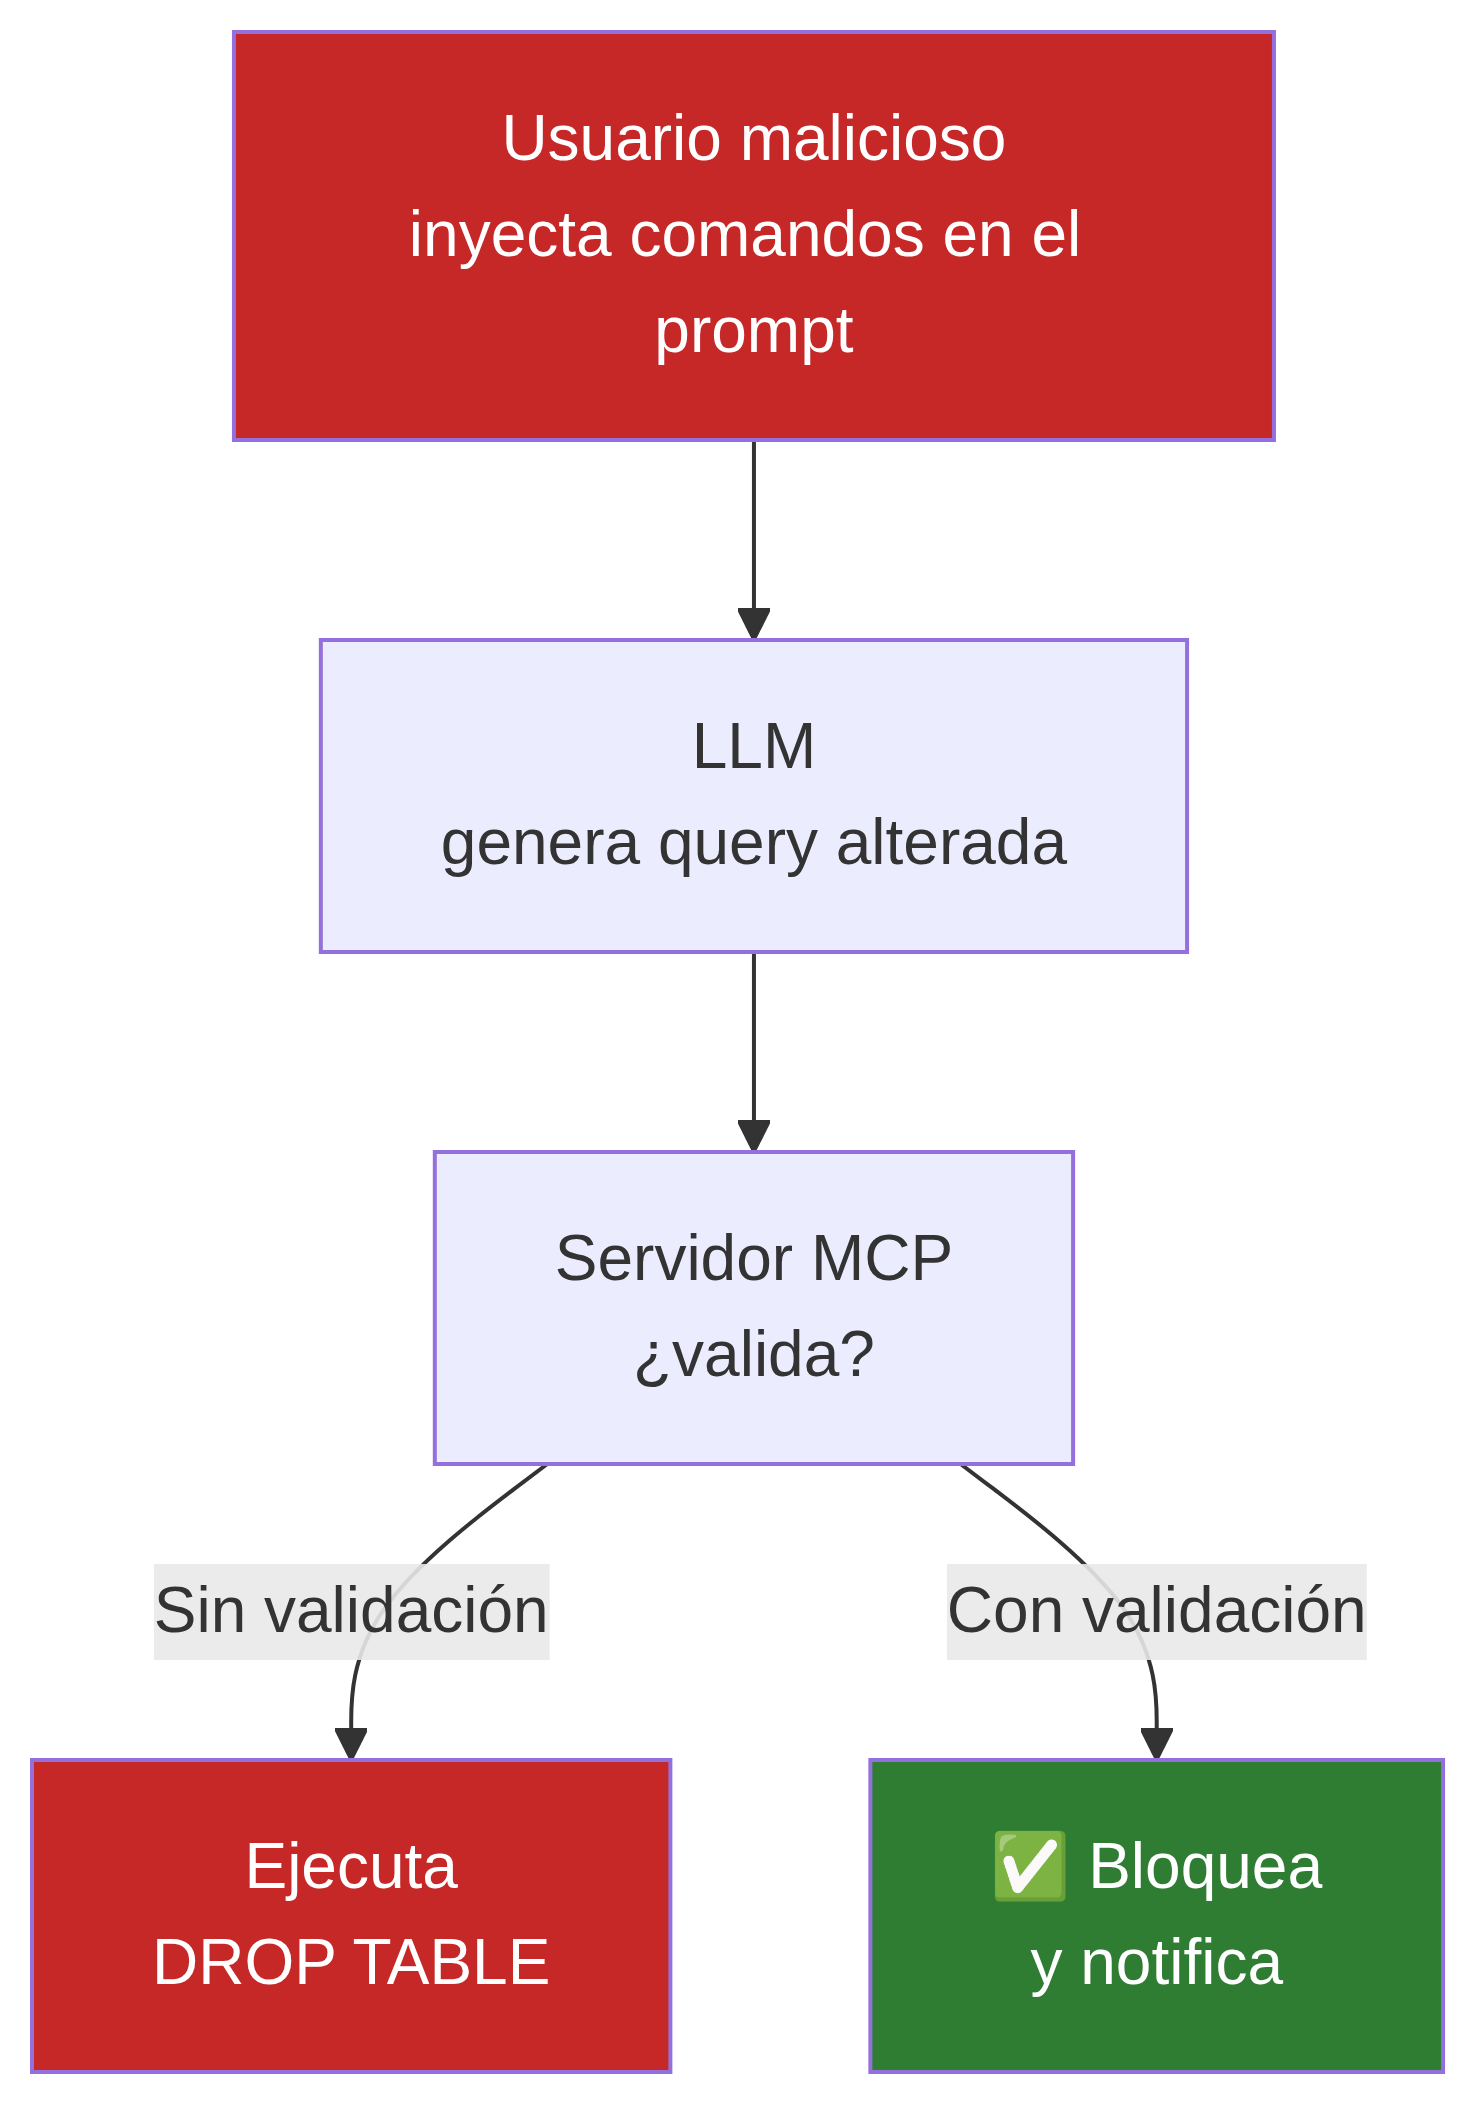

## 5.1 Añadir sanitización

In [23]:
# ─── COMPLETAR: implementa la sanitización de queries SQL ───
PALABRAS_PROHIBIDAS = ["DROP", "DELETE", "UPDATE", "INSERT", "ALTER", "CREATE", "TRUNCATE"]

def sanitizar_query(query: str) -> str:
    """
    Valida y limpia una consulta SQL. Solo permite SELECT.

    Args:
        query: consulta SQL del usuario.

    Returns:
        La query original si es segura.

    Raises:
        ValueError si la query contiene comandos peligrosos.
    """
    # TODO: Convertir query a mayúsculas para comparar
    # TODO: Recorrer PALABRAS_PROHIBIDAS y lanzar ValueError si aparece alguna
    # TODO: Verificar que la query empieza por SELECT
    return query  # ← completar

# ─── COMPLETAR: actualiza consultar_sql para usar sanitizar_query ───
# Añade al principio de consultar_sql:
#   query = sanitizar_query(query)
# Si sanitizar_query lanza ValueError, captúralo y devuelve el mensaje de error

print("✅ Función sanitizar_query definida.")

✅ Función sanitizar_query definida.

## 5.2 Probar ataques de prompt injection

Ejecutamos varios intentos de ataque para verificar que nuestras
defensas funcionan.

In [24]:
print("=" * 60)
print("TEST DE SEGURIDAD — Prompt Injection")
print("=" * 60)

ataques = [
    "DROP TABLE empleados",
    "DELETE FROM proyectos WHERE estado = 'finalizado'",
    "INSERT INTO empleados VALUES (99, 'Hacker', 'IT', 999999, 0)",
    "UPDATE empleados SET salario = 0",
    "SELECT * FROM empleados; DROP TABLE horas; --",
]

# ─── COMPLETAR: prueba cada ataque contra sanitizar_query ───
for ataque in ataques:
    # TODO: Llamar a sanitizar_query(ataque) dentro de try/except
    # TODO: Si lanza ValueError → ✅ Bloqueado
    # TODO: Si no lanza → ❌ Peligro
    print(f"  ? {ataque}")
    pass  # ← completar

print("\n⚠️  Completa el bucle para ver los resultados de cada ataque.")

TEST DE SEGURIDAD — Prompt Injection
  ? DROP TABLE empleados
  ? DELETE FROM proyectos WHERE estado = 'finalizado'
  ? INSERT INTO empleados VALUES (99, 'Hacker', 'IT', 999999, 0)
  ? UPDATE empleados SET salario = 0
  ? SELECT * FROM empleados; DROP TABLE horas; --

⚠️  Completa el bucle para ver los resultados de cada ataque.

## 5.3 Límite de resultados

In [25]:
# ─── COMPLETAR: añade límite de filas a consultar_sql ───
# Después de ejecutar la query, limita la salida a un máximo de 30 filas.
# Si hay más de 30, muestra las primeras 30 y añade "... y N filas más".

# También añade límite de caracteres: si el resultado supera 2000 caracteres, trunca.

print("⚠️  Implementa el límite de filas en consultar_sql.")

⚠️  Implementa el límite de filas en consultar_sql.

## 5.4 Checklist de seguridad

> **Rellena este checklist**
>
> Marca con ✅ lo que has implementado (los que queden vacíos son
> mitigaciones que añadirías en producción):
>
> | Riesgo | Mitigación |
> |------------------------------------|------------------------------------|
> | SQL Injection vía prompt | Solo permitir SELECT, sanitizar query |
> | Data leakage (demasiadas filas) | Limitar a 30 filas, 2000 caracteres |
> | Path traversal (si expusieras archivos) | Validar rutas con `os.path.abspath` |
> | Denegación de servicio | Timeout en queries (máx. 5s) |
> | Acceso no autorizado | API keys en transporte, logs de auditoría |
> | Escalada de privilegios | Cada tool accede solo a lo que necesita |
>
> - [ ] SQL Injection vía prompt
> - [ ] Data leakage (demasiadas filas)
> - [ ] Path traversal (si expusieras archivos)
> - [ ] Denegación de servicio
> - [ ] Acceso no autorizado
> - [ ] Escalada de privilegios

> **Stdio vs. HTTP: implicaciones de seguridad**
>
> El transporte **stdio** que usamos aquí es seguro por diseño: sin red,
> sin puertos expuestos. Si en producción expones tu servidor MCP por
> **HTTP/SSE**, necesitas añadir: TLS (HTTPS), autenticación por token o
> API key, y rate limiting. El resto del checklist (sanitización,
> límites, mínimo privilegio) aplica en ambos casos.

------------------------------------------------------------------------

# Parte 6 — Batería de pruebas

Probamos el servidor MCP con preguntas de dificultad creciente. Observa
qué herramienta elige el LLM para cada caso.

In [26]:
preguntas_prueba = [
    # Nivel 1: consulta simple → debería usar consultar_sql
    "¿Cuántos empleados hay en el departamento de Finanzas?",

    # Nivel 2: búsqueda por ID → debería usar empleado_por_id
    "Dame los datos del empleado con ID 7",

    # Nivel 3: resumen agregado → debería usar resumen_proyecto
    "¿Cuál es el estado actual del proyecto Alpha y cuántas horas se han imputado?",

    # Nivel 4: consulta compleja → debería usar consultar_sql
    "¿Qué departamento tiene el presupuesto total más alto en proyectos activos?",

    # Nivel 5: múltiples pasos → podría combinar varias tools
    "Dime qué empleados han trabajado en el proyecto de mayor presupuesto y cuántas horas cada uno",
]

if not LLM_KEY:
    print("⚠️  Configura LLM_API_KEY en .env para ver la batería de pruebas.")
else:
    for i, pregunta in enumerate(preguntas_prueba, 1):
        print(f"\n{'='*70}")
        print(f"PREGUNTA {i}: {pregunta}")
        print('='*70)
        try:
            # respuesta = preguntar_al_llm(pregunta)
            # print(f"\nRESPUESTA FINAL: {respuesta}")
            print("⚠️  Descomenta cuando hayas implementado preguntar_al_llm().")
        except Exception as e:
            print(f"ERROR: {e}")


PREGUNTA 1: ¿Cuántos empleados hay en el departamento de Finanzas?
⚠️  Descomenta cuando hayas implementado preguntar_al_llm().

PREGUNTA 2: Dame los datos del empleado con ID 7
⚠️  Descomenta cuando hayas implementado preguntar_al_llm().

PREGUNTA 3: ¿Cuál es el estado actual del proyecto Alpha y cuántas horas se han imputado?
⚠️  Descomenta cuando hayas implementado preguntar_al_llm().

PREGUNTA 4: ¿Qué departamento tiene el presupuesto total más alto en proyectos activos?
⚠️  Descomenta cuando hayas implementado preguntar_al_llm().

PREGUNTA 5: Dime qué empleados han trabajado en el proyecto de mayor presupuesto y cuántas horas cada uno
⚠️  Descomenta cuando hayas implementado preguntar_al_llm().

## Tabla de evaluación

Completa esta tabla con tus observaciones sobre cada pregunta:

    ┌────┬──────────────────────────────────────────┬─────────────────┬──────────┬─────────────────────────┐
    │  # │ Pregunta                                 │ Tool(s) usada   │ ¿Correcto?│ Observaciones           │
    ├────┼──────────────────────────────────────────┼─────────────────┼──────────┼─────────────────────────┤
    │  1 │ Empleados en Finanzas                    │                 │   / 5    │                         │
    │  2 │ Datos del empleado 7                     │                 │   / 5    │                         │
    │  3 │ Resumen proyecto Alpha                   │                 │   / 5    │                         │
    │  4 │ Dpto con más presupuesto activo          │                 │   / 5    │                         │
    │  5 │ Empleados del proyecto más caro          │                 │   / 5    │                         │
    └────┴──────────────────────────────────────────┴─────────────────┴──────────┴─────────────────────────┘

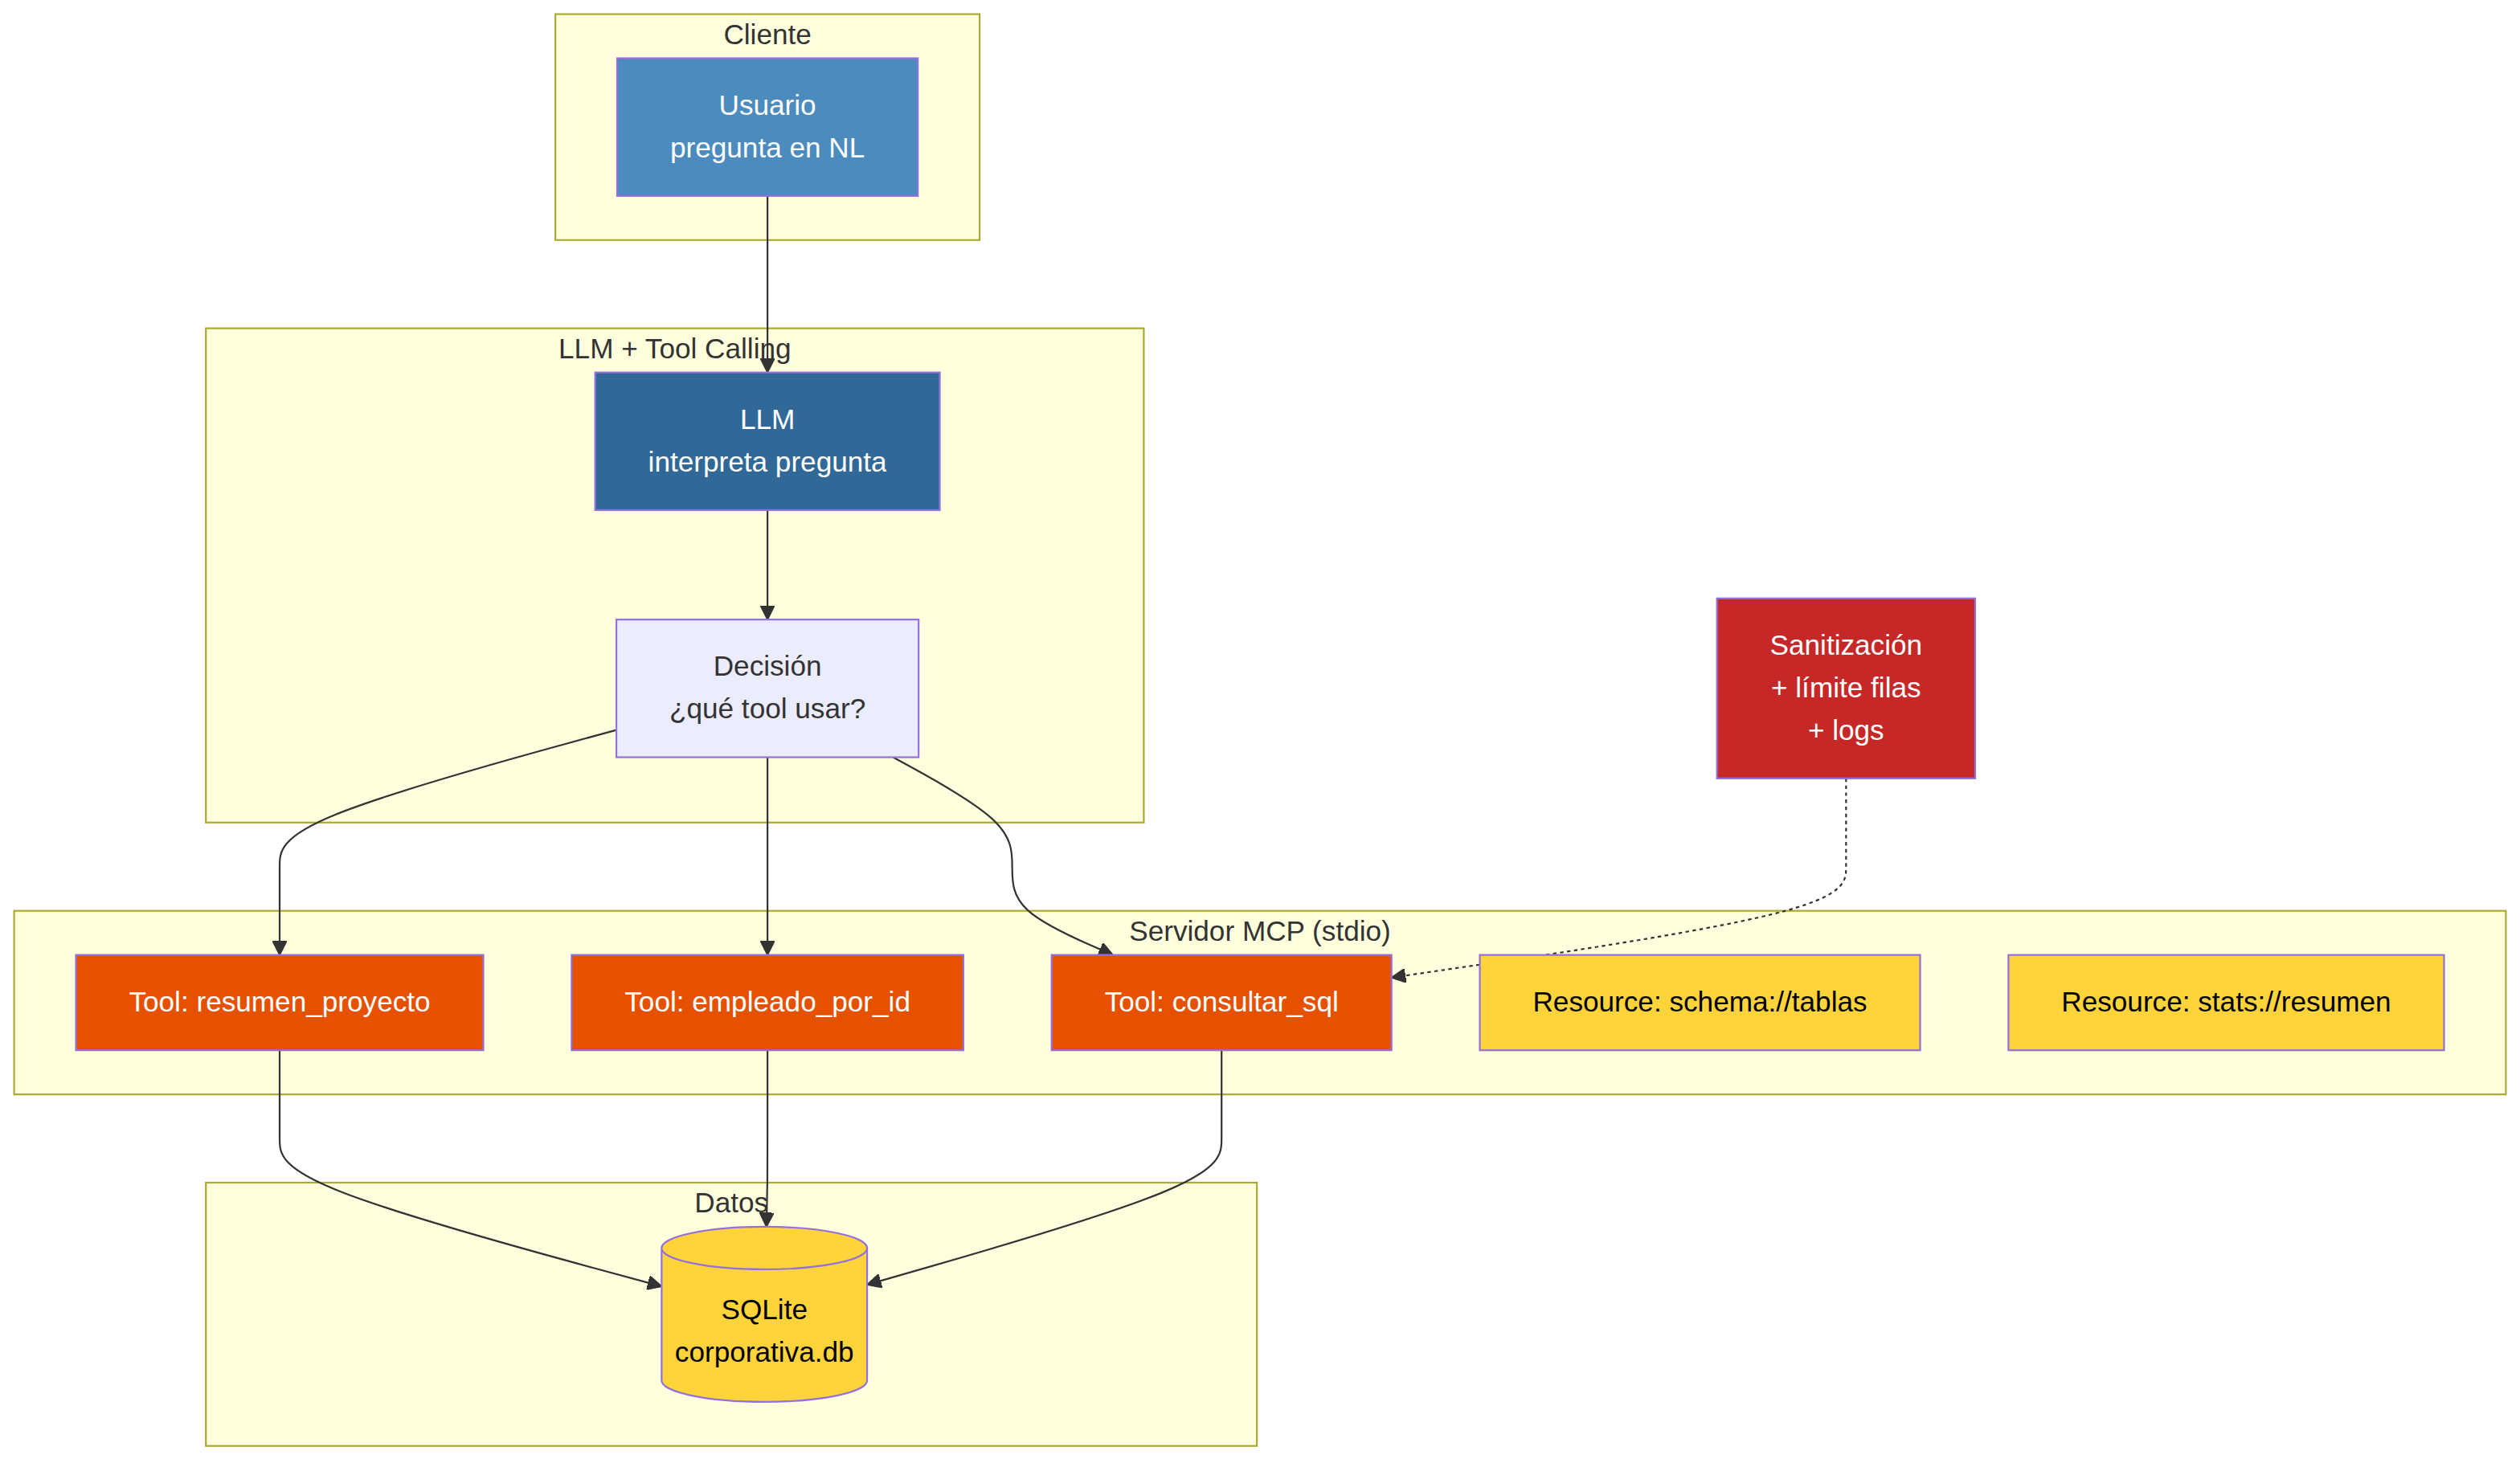

------------------------------------------------------------------------

# Ejercicios

> **Para afianzar lo aprendido (~45 min)**
>
> Estos ejercicios no se entregan, pero te preparan para el HPD 3
> evaluable y el proyecto integrador.
>
> ------------------------------------------------------------------------
>
> **A1 — Añade una tool empleados_por_departamento (~15 min)**
>
> Crea `@mcp.tool() empleados_por_departamento(departamento: str)` que
> devuelva la lista de empleados de un departamento con formato:
> `nombre | salario | antiguedad_años`. Si el departamento no existe,
> devuelve un mensaje con los departamentos disponibles.
>
> > **Note**
> >
> > **Objetivo:** entender que añadir tools especializadas reduce la
> > carga del LLM (no necesita escribir SQL para consultas simples).
>
> ------------------------------------------------------------------------
>
> **A2 — Añade un resource presupuesto://total (~15 min)**
>
> Crea `@mcp.resource("presupuesto://total")` que devuelva el
> presupuesto total de todos los proyectos + desglose por departamento.
>
> > **Note**
> >
> > **Objetivo:** distinguir tools (acciones que modifican o consultan
> > con parámetros) de resources (datos estáticos de solo lectura).
>
> ------------------------------------------------------------------------
>
> **A3 — Modifica el system prompt del cliente (~15 min)**
>
> Cambia el mensaje `system` de `preguntar_al_llm()` para que el
> asistente: - Se niegue a ejecutar queries que contengan nombres de
> tablas no listados en el schema - Exija que toda query incluya al
> menos una condición WHERE - Responda en formato bullet points en lugar
> de texto libre
>
> Prueba con 3 preguntas y compara el comportamiento con el prompt
> original.
>
> > **Note**
> >
> > **Objetivo:** comprobar que el system prompt es tu primera línea de
> > defensa.
>
> ------------------------------------------------------------------------
>
> ### Para seguir explorando (opcional)
>
> **E1 — Añade una tool de auditoría**
>
> Crea `@mcp.tool() auditoria()` que lea de una tabla
> `auditoria(id, timestamp, query, resultado, bloqueado)` que se rellena
> automáticamente desde `consultar_sql`. Cada vez que alguien ejecuta
> una consulta, se registra el timestamp, la query, el resultado
> (truncado a 200 caracteres) y si fue bloqueada por sanitización.
>
> **E2 — Implementa rate limiting**
>
> Modifica `consultar_sql` para que solo permita 10 consultas por
> minuto. Si se supera el límite, devuelve
> `"Límite de consultas alcanzado. Espera X segundos."`
>
> **E3 — Servidor MCP real con stdio**
>
> Investiga cómo lanzar el servidor MCP como script independiente
> (`python servidor_mcp.py`) y conectarte desde un cliente usando
> `fastmcp.Client`. El código base está en
> [02d-mcp.qmd](02d-mcp.qmd#servidor-mcp-completo-para-ejecutar-como-script).
> Adapta tu servidor a ese formato y pruébalo con Ollama local.
>
> **E4 — Conecta MCP a tu agente de HPD 2**
>
> Sustituye una de las tools de LangChain de tu agente del HPD 2 por una
> tool que invoque tu servidor MCP. El agente no debería notar la
> diferencia — esa es la magia de MCP.

------------------------------------------------------------------------

> **Entregable**
>
> - Servidor MCP funcional con al menos 3 tools + 2 resources
> - Log de las 5 preguntas de prueba con sus respuestas
> - Checklist de seguridad completado
> - Tabla de evaluación completada
>
> ## Criterios de evaluación
>
> - Servidor MCP operativo con herramientas funcionales
> - Cliente LLM capaz de seleccionar la tool correcta para cada pregunta
> - Sanitización SQL implementada y probada
> - Análisis de riesgos con mitigaciones concretas
>
> ## Tiempo estimado: 4h